# Análisis Exploratorio — Propiedades Medellín

In [129]:
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [130]:
#csv_path = "https://dwwzqwcoqlasgvpniwiu.supabase.co/storage/v1/object/public/Data_bucket/aa/propiedades_medellin_raw.csv"
csv_path = "C:\\Users\\Acer\\Desktop\\prueba_inmobiliaria\\propiedades_medellin_raw.csv"
df = pd.read_csv(csv_path, encoding="utf-8-sig")

print(f"Filas    : {df.shape[0]:,}")
print(f"Columnas : {df.shape[1]}")
print("\nColumnas:", df.columns)


Filas    : 1,240
Columnas : 8

Columnas: Index(['id_propiedad', 'nombre_anuncio', 'precio_venta', 'metraje_m2',
       'estrato_socioeconomico', 'ubicacion', 'tipo_inmueble',
       'fecha_publicacion'],
      dtype='object')


In [131]:
df.head(15)

,id_propiedad,nombre_anuncio,precio_venta,metraje_m2,estrato_socioeconomico,ubicacion,tipo_inmueble,fecha_publicacion
0,681,Casa en Sabaneta,1989000000,249,2.0,SABANETA,Casa,"Oct 15, 2023"
1,377,Propiedad en Centro - Medellín,1514000000,359,6.0,Centro - Medellín,?,15/10/2023
2,1084,Casa en El Poblado,822000000,227,4.0,El Poblado,Casa,2023.10.15
3,948,Casa en El Poblado,828000000,44,2.0,El Poblado,Casa,15/10/2023
4,1017,None en Robledo,1226000000,353,4.0,ROBLEDO,NaN,15/10/2023
5,84,None en Centro,2009000000,269,2.0,Centro,NaN,2023-10-15
6,356,Casa en Centro,2464000000,367,2.0,Centro,Casa,2023-10-15
7,752,Apartestudio en Laureles - Estadio,1922000000,403,2.0,Laureles - Estadio,Apartestudio,15/10/2023
8,1147,Propiedad en Robledo,$ 2.441.000.000,327,2.0,Robledo,?,"Oct 15, 2023"
9,780,Apartestudio en Envigado,$ 2.375.000.000,0,5.0,ENVIGADO,Apartestudio,2023.10.15


**Observación:** aparecen literales `None` en `nombre_anuncio`, precios con formato `$ 2.441.000.000` y ubicaciones en distintos formatos. Se debe normalizar placeholders (`None`, `?`) y limpiar formatos numéricos.

In [132]:
df.dtypes

id_propiedad                int64
nombre_anuncio             object
precio_venta               object
metraje_m2                  int64
estrato_socioeconomico    float64
ubicacion                  object
tipo_inmueble              object
fecha_publicacion          object
dtype: object

Hay que cambiar tipo en precio, estrato y fecha

In [133]:
df.isnull().sum()

id_propiedad                0
nombre_anuncio              0
precio_venta                0
metraje_m2                  0
estrato_socioeconomico    127
ubicacion                   0
tipo_inmueble             124
fecha_publicacion           0
dtype: int64

In [134]:
# Duplicados exactos: mismo id Y mismo precio
print("Duplicados exactos (id + precio):", df.duplicated(subset=["id_propiedad", "precio_venta"]).sum())

# Duplicados solo por id — si es mayor que el anterior, hay ids con precio distinto
print("Duplicados por id solo          :", df.duplicated(subset=["id_propiedad"]).sum())




Duplicados exactos (id + precio): 40
Duplicados por id solo          : 40


In [135]:
print("duplicados",df.duplicated().sum())

duplicados 40


In [136]:
dup_id = df.duplicated(subset=["id_propiedad"]).sum()
dup_id_precio = df.duplicated(subset=["id_propiedad", "precio_venta"]).sum()
print(f"Mismo id, precio distinto       : {dup_id - dup_id_precio}")

Mismo id, precio distinto       : 0


**Observación:** se detectaron `id_propiedad` duplicados, todas con los mismo valores, pero no se descarta que en carga recurrente pueda llegar con precio de venta diferente

In [137]:
ubicaciones = df["ubicacion"].value_counts(dropna=False)
print(f"Valores unicos: {df['ubicacion'].nunique(dropna=False)}")
print()
print(ubicaciones.to_string())

Valores unicos: 19

ubicacion
Laureles              81
laureles              78
BELEN                 76
ROBLEDO               74
ENVIGADO              71
Centro - Medellín     67
Belén                 65
poblado               65
EL HUECO              65
Centro                64
El Poblado            64
SABANETA              63
Envigado              62
Laureles - Estadio    61
Robledo               61
EL POBLADO            59
Belen                 58
Sabaneta              56
POBLADO               50


**Observación:** 19 variantes para 8 zonas reales — diferencias de casing, tildes y sufijos (`El Poblado`, `POBLADO`, `poblado`, `Laureles - Estadio`)

In [138]:
# tipo_inmueble — cuántos inválidos hay y qué valores exactos
print(df["tipo_inmueble"].value_counts(dropna=False).to_string())

tipo_inmueble
Finca           254
Apartamento     251
Casa            249
Apartestudio    241
NaN             124
?               121


**Observación:** existen valores ? y celdas vacías. Se mapean a `Sin clasificar` en la tabla maestra. No son recuperables desde `nombre_anuncio` — cuando el tipo es `?` el nombre dice `Propiedad en...`; cuando está vacío dice `None en...`.

In [139]:
print("Valores únicos de estrato_socioeconomico:")
print(df["estrato_socioeconomico"].value_counts(dropna=False).to_string())
print(f"\nTipo pandas detectado: {df['estrato_socioeconomico'].dtype}")
print(f"Nulos: {df['estrato_socioeconomico'].isna().sum()}")


Valores únicos de estrato_socioeconomico:
estrato_socioeconomico
2.0    239
6.0    229
3.0    218
5.0    214
4.0    213
NaN    127

Tipo pandas detectado: float64
Nulos: 127


**Observación:** tipo float64 con valores como `2.0`, `3.0`. Se convierte a `int` y se mapea a tabla maestra `estrato`. Los nulos se asignan al registro `Sin estrato`.

In [140]:
print("Muestra de valores únicos de fecha_publicacion:")
print(df["fecha_publicacion"].value_counts(dropna=False).head(20).to_string())

Muestra de valores únicos de fecha_publicacion:
fecha_publicacion
15/10/2023      322
2023-10-15      320
2023.10.15      310
Oct 15, 2023    288


**Observación:** se detectaron múltiples formatos (ej. Oct 15, 2023, 15/10/2023, 2023.10.15).

In [141]:
# metraje_m2 — valores inválidos (cero o negativos)
invalidos = df[df["metraje_m2"] <= 1]["metraje_m2"].value_counts()
print(f"Registros con metraje <= 1: {(df['metraje_m2'] <= 1).sum()}")
print(invalidos.to_string())

Registros con metraje <= 1: 62
metraje_m2
 1     23
-50    23
 0     16


**Observación (metraje):** hay valores `0`, `1` y negativos (`-50`) que no tienen sentido físico; en ETL marcarlos como NULL y, si es posible, consultar la fuente para corregirlos.

### `precio_venta` — distribución y outliers

In [142]:
#Qué tan sucios están los valores antes de limpiar
print('Muestra de valores raw de precio_venta:')
print(df['precio_venta'].value_counts(dropna=False).head(20).to_string())

Muestra de valores raw de precio_venta:
precio_venta
2323000000    4
877000000     4
909000000     3
1625000000    3
1093000000    3
2159000000    3
574000000     3
1514000000    3
2293000000    3
516000000     3
756000000     3
2420000000    3
338000000     3
1007000000    3
413000000     3
2129000000    3
1573000000    3
2370000000    3
1218000000    3
461000000     3


In [143]:
s_precio = pd.to_numeric(df['precio_venta'], errors='coerce')
print(s_precio.isna().sum())

357


In [144]:
print("Valores con $:", df["precio_venta"].astype(str).str.contains(r'\$').sum())

Valores con $: 357


In [145]:
s_precio = (
    df['precio_venta']
    .astype(str)
    .str.replace(r'[\$\.\s]', '', regex=True)
    .pipe(pd.to_numeric, errors='coerce')
)

s_precio

0       1989000000
1       1514000000
2        822000000
3        828000000
4       1226000000
           ...    
1235    1041000000
1236    1895000000
1237    1351000000
1238    1209000000
1239    1236000000
Name: precio_venta, Length: 1240, dtype: int64

In [146]:
print(f'Nulos reales  : {s_precio.isna().sum()}')
print(f'Min           : {s_precio.min():,.0f}')
print(f'Max           : {s_precio.max():,.0f}')

Nulos reales  : 0
Min           : 200,000,000
Max           : 2,498,000,000


**Observación (precio_venta):** `pd.to_numeric` directo sobre el raw convierte a `NaN` los valores con formato `$ 2.441.000.000` — el dato existe pero el símbolo y los puntos de miles impiden el casteo. Tras limpiar (quitar `$`, puntos y espacios) los nulos reales son solo los campos vacíos en el CSV. limpiar formato antes de castear si aún quedan nulos o menores a cero se descarta el anuncio completo

### `metraje_m2` — distribución y outliers

In [147]:
s_metraje = pd.to_numeric(df['metraje_m2'], errors='coerce')
s_metraje_valid = s_metraje[s_metraje > 0].dropna()

In [148]:
print("Distribución de metrajes bajos (1-20 m²):")
print(
    s_metraje_valid[s_metraje_valid <= 20]
    .value_counts()
    .sort_index()
    .to_string()
)

Distribución de metrajes bajos (1-20 m²):
metraje_m2
1    23


In [149]:
s_metraje = pd.to_numeric(df['metraje_m2'], errors='coerce')
s_metraje_valid = s_metraje[s_metraje > 0].dropna()

q1m, q3m = s_metraje_valid.quantile(0.25), s_metraje_valid.quantile(0.75)
iqrm = q3m - q1m

print(f'Valores <= 0         : {(s_metraje <= 0).sum()}')
print(f'Metraje min (válido) : {s_metraje_valid.min():.0f} m²')
print(f'Percentil  5         : {s_metraje_valid.quantile(0.05):.0f} m²')
print(f'Mediana              : {s_metraje_valid.median():.0f} m²')
print(f'Percentil 95         : {s_metraje_valid.quantile(0.95):.0f} m²')
print(f'Metraje max          : {s_metraje_valid.max():.0f} m²')
print(f'Outliers IQR         : {((s_metraje_valid < q1m-1.5*iqrm) | (s_metraje_valid > q3m+1.5*iqrm)).sum()}')
print(f'Metraje 1-5 m²       : {((s_metraje_valid >= 1) & (s_metraje_valid <= 5)).sum()}')
print(f'Metraje > 400 m²     : {(s_metraje_valid > 400).sum()}')

Valores <= 0         : 39
Metraje min (válido) : 1 m²
Percentil  5         : 48 m²
Mediana              : 236 m²
Percentil 95         : 427 m²
Metraje max          : 450 m²
Outliers IQR         : 0
Metraje 1-5 m²       : 23
Metraje > 400 m²     : 131


C:\Users\Acer\AppData\Local\Temp\ipykernel_29900\1799060205.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


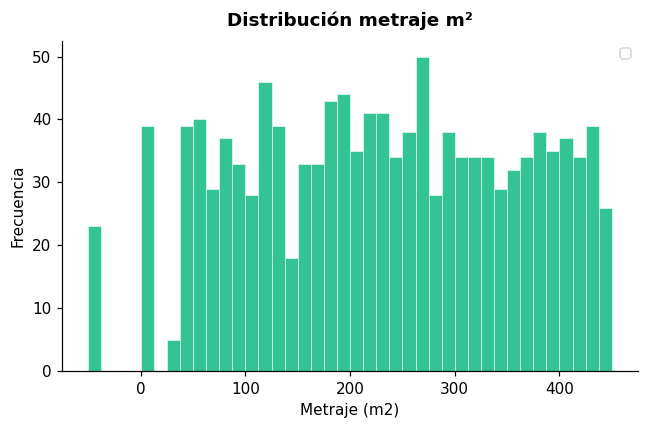

In [150]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    s_metraje,
    bins=40,
    color='#10b981',
    alpha=0.85,
    edgecolor='white',
    linewidth=0.4
)

ax.set_title('Distribución metraje m²', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Metraje (m2)')
ax.set_ylabel('Frecuencia')


ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Observación (metraje_m2):** 39 valores `<= 0` son errores físicos imposibles. 23 registros de 1 sospechosos. 131 registros sobre 400 son posibles dado que el dataset incluye fincas. No hay outliers por IQR. Valores `<= 1` pasan a `NULL`

### nombre_anuncio — ¿es un campo calculado?`

**Hipótesis:** el nombre es siempre la concatenación de 
`tipo_inmueble + " en " + ubicacion`.

In [151]:
def normalizar(texto):
    """Lowercase + strip + colapsa espacios."""
    return re.sub(r"\s+", " ", str(texto).strip().lower())

In [152]:
df["nombre_original_norm"] = df["nombre_anuncio"].apply(normalizar)

In [153]:
def reconstruir_nombre(row):
    tipo_raw = row["tipo_inmueble"]
    ubic = normalizar(str(row["ubicacion"]).strip())

    if pd.isna(tipo_raw) or str(tipo_raw).strip() == "":
        return "none en " + ubic
    
    tipo = normalizar(str(tipo_raw).strip())
    
    if tipo == "?":
        return "propiedad en " + ubic
    
    return tipo + " en " + ubic

In [154]:

df["nombre_reconstruido"] = df.apply(reconstruir_nombre, axis=1)

df[["nombre_anuncio", "nombre_original_norm", "nombre_reconstruido"]].head(8)

,nombre_anuncio,nombre_original_norm,nombre_reconstruido
0,Casa en Sabaneta,casa en sabaneta,casa en sabaneta
1,Propiedad en Centro - Medellín,propiedad en centro - medellín,propiedad en centro - medellín
2,Casa en El Poblado,casa en el poblado,casa en el poblado
3,Casa en El Poblado,casa en el poblado,casa en el poblado
4,None en Robledo,none en robledo,none en robledo
5,None en Centro,none en centro,none en centro
6,Casa en Centro,casa en centro,casa en centro
7,Apartestudio en Laureles - Estadio,apartestudio en laureles - estadio,apartestudio en laureles - estadio


In [155]:
coincide = (df["nombre_original_norm"] == df["nombre_reconstruido"]).sum()
total = len(df)

print(f"Coincidencia: {coincide}/{total} ({coincide/total*100:.1f}%)")


Coincidencia: 1240/1240 (100.0%)


**Hipotesis confirmada — 1240/1240 (100%)**

nombre_anuncio es un campo derivado: siempre es tipo_inmueble + " en " + ubicacion.

No se necesita en la tabla `propiedad`. Se puede reconstruir como vista


---

## Resumen consolidado

---

### Hallazgos del EDA

**`id_propiedad`**
40 IDs duplicados exactos, todos los duplicados son el mismo registro repetido exacto.

**`tipo_inmueble`**
124 nulos y 121 registros con `'?'` — 245 registros sin tipo real. No son recuperables desde `nombre_anuncio`: cuando el tipo es `'?'` el nombre dice `'Propiedad en...'`, cuando está vacío dice `'None en...'`. 

**`ubicacion`**
19 variantes textuales para 8 zonas reales. Diferencias de casing, tildes y sufijos (`Laureles`, `laureles`, `Laureles - Estadio`) cero nulos.

**`estrato_socioeconomico`**
Tipo `float64` en pandas (`2.0`, `3.0`...). 127 nulos. Los estratos presentes son 2, 3, 4, 5 y 6 — estrato 1 no aparece en el dataset.

**`fecha_publicacion`**
4 formatos distintos en la misma columna. Todos los 1.240 registros caen en uno de los cuatro — detectado empíricamente: `15/10/2023` (322), `2023-10-15` (320), `2023.10.15` (310), `Oct 15, 2023` (288). Cero nulos

**`metraje_m2`**
62 valores físicamente imposibles: 23 negativos (`-50`), 16 ceros, 23 con valor `1`. En el rango 1-20 m² solo existe el valor `1` — no hay valores entre 2 y 20. Mediana 236 m², percentil 95 en 427 m². Sin outliers por IQR. 131 registros sobre 400 m² son plausibles dado que el dataset incluye fincas.

**`precio_venta`**
Tipo `object` en pandas. 357 valores con formato `$ 2.441.000.000` que `pd.to_numeric` directo convierte a `NaN` — el dato existe pero el símbolo y los puntos de miles impiden el casteo. Tras limpiar: cero nulos reales. Rango limpio: mínimo $200.000.000, máximo $2.498.000.000

**`nombre_anuncio`**
100% derivado — verificado empíricamente sobre 1.240/1.240 registros (100%). Siempre es `tipo_inmueble + ' en ' + ubicacion`. No agrega información, la refleja con sus propios errores.

---

### Decisiones de negocio

**El CSV mezcla dos entidades distintas.**
`precio_venta` y `fecha_publicacion` no son atributos del inmueble físico — son atributos de la publicación comercial. Una misma propiedad puede publicarse varias veces con precios y fechas distintas. En el modelo separo esto en dos tablas: `propiedad` (el inmueble, estable) y `anuncio` (la publicación, variable en el tiempo). Con el CSV actual la relación es 1 a 1, pero la separación eprmite tener un historial de precios y análisis de series temporales sin cambios estructurales futuros.

**Una propiedad sin zona no es útil.**
Sin zona no es ubicable ni consultable. Se descarta. Es el único campo cuya ausencia invalida el registro completo.

**Un anuncio sin precio no es una publicación real.**
357 valores con `$` son recuperables — no son nulos reales. Post-limpieza no quedan nulos de precio. Si en una carga futura llegara precio vacío o `<= 0`, se descarta el anuncio, no la propiedad.

**Un anuncio sin fecha no puede existir en el modelo.**
`(id_propiedad, fecha_publicacion)` es el índice único de `anuncio`. Sin fecha no hay forma de distinguirlo de otros anuncios de la misma propiedad. Se descarta.

**Los duplicados son registros exactos, no actualizaciones.**
Los 40 duplicados tienen el mismo id y el mismo precio — no hay casos de mismo id con precio distinto. `keep='first'` en `df_propiedad` y `keep='last'` en `df_anuncio` producen el mismo resultado para este CSV. La separación se mantiene porque en cargas futuras puede haber actualizaciones reales de precio.

**Anuncio cuya propiedad no viene en esta carga.**
Si el `id_propiedad` no está en `df_propiedad_validas` de esta ejecución, puede existir en la BD de una carga anterior. En producción la FK lo resuelve

**Estrato 1 no aparece en el dataset.**
No se modela como ausente — simplemente no hay registros

**`nombre_anuncio` no se persiste.**
Dos razones independientes: es 100% derivado (redundancia real), y el identificador del anuncio debe ser una clave técnica (`id_anuncio`), no un texto descriptivo.

---

### Reglas del ETL

**`tipo_inmueble`**
`'?'` y vacío pasa a `'Sin clasificar'`. El registro no se descarta.

**`ubicacion`**
Normalizar (lowercase + strip + quitar tildes) y aplicar `ZONA_MAPPING`. Sin mapeo la propiedad es rechazada y logueada.

**`estrato_socioeconomico`**
Convertir `float` a `int`. Nulos pasan a `'Sin estrato'`.

**`fecha_publicacion`**
Parsear con 4 patrones en orden, normalizar a `YYYY-MM-DD`. Formato desconocido o vacío pasan a `NULL` y en anuncio es descartado. En el reporte distinguir entre campo vacío y formato no reconocido.

**`metraje_m2`**
`<= 1` pasa a `NULL`. No existe ningún valor entre 2 y 20 m². Propiedad no se descarta.

**`precio_venta`**
Limpiar formato (quitar `$`, puntos de miles, espacios) antes de castear. `NULL` o `<= 0` post-limpieza el anuncio es descartado.

**Construcción de `df_propiedad`**
deduplicación por `id_propiedad` keep `'first'`. Rechazar filas sin `id_zona`. 

**Construcción de `df_anuncio`**
deduplicación por `(id_propiedad, fecha_clean)` keep `'last'`. Descartar filas sin fecha o sin precio.Si el anuncio es la publicación comercial — el último registro del día es el más actualizado.

**Orden de carga**
Maestras primero (`municipio`, `zona`, `tipo_inmueble`, `estrato`), luego `propiedad`, luego `anuncio`. La FK de `anuncio` sobre `propiedad` exige que la propiedad exista antes.

**Idempotencia**
`ON CONFLICT DO NOTHING` en maestras y `propiedad`. `ON CONFLICT (id_propiedad, fecha_publicacion) DO UPDATE SET precio_venta = EXCLUDED.precio_venta` en `anuncio` — si el mismo anuncio llega con precio corregido en una carga posterior, se actualiza.